# Pronóstico de Ventas: Regresión Múltiple vs. Series de Tiempo (Box-Jenkins) para Vanish y Lysol

**Categoría de mercado:** Productos de limpieza para el hogar (canal autoservicio, México)

**Rol:** Modelado predictivo, validación y análisis end-to-end (individual)

**Stack:** Python · pandas · NumPy · statsmodels · scikit-learn · Matplotlib

### Contexto

Este proyecto parte del mismo dataset consolidado del [pipeline ETL](https://github.com/ReginaPema/etl-sales-data-cleaning), para desarrollar una línea de análisis con objetivo predictivo, con su propio análisis exploratorio enfocado en las series de tiempo. Se comparan dos familias de modelos, regresión lineal múltiple y series de tiempo (metodología Box-Jenkins: ARIMA/SARIMA), para pronosticar el valor de venta semanal a **nivel nacional** de **Vanish** y **Lysol**, dos marcas clave del segmento *Fabric Treatment and
Sanitizers*, justificando la elección de modelo con base en los patrones observados en los datos históricos.

### Objetivo

1. Cargar y preparar la serie de tiempo semanal de Vanish y Lysol.
2. Explorar la serie de tiempo (tendencia, estacionalidad, estacionariedad) con su propio EDA.
3. Comparar regresión lineal múltiple contra ARIMA/SARIMA y justificar la elección de técnica según
   los patrones observados.
4. Construir, entrenar y validar el modelo elegido siguiendo la metodología Box-Jenkins.
5. Ajustar y comparar modelos candidatos para seleccionar el de mejor desempeño.
6. Generar un pronóstico a futuro debidamente validado.

### Nota metodológica

Para pronosticar a nivel nacional, las filas de `Total Nacional` se usan de forma directa e intencional, como el nivel de agregación correcto para esta pregunta de negocio.

### Resultado

Un modelo de pronóstico distinto para cada marca, elegido según su propio comportamiento histórico: SARIMA(1,1,1)(1,0,1,13) para Vanish y ARIMA(0,1,0) en escala logarítmica para Lysol, con su validación y comparación contra la alternativa de regresión múltiple documentadas paso a paso.

---

# 1. Carga y preparación de los datos

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)

df = pd.read_parquet("df_consolidado_final.parquet")

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [16]:
print("Dimensiones:", df.shape)
df.head(3)

Dimensiones: (122002, 47)


,item_code,manufacturer,brand,item_description,id_category,category,segment,format,attr1,attr2,attr3,size,size_num,size_unit,date,day_number,day_name,week_number,week_year,month,month_name,quarter,year_month,year_quarter,month_period,year,region,region_type,region_clean,region_short,total_unit_sales,total_value_sales,total_unit_avg_weekly_sales,avg_weekly_price,var_weekly_avg,var_pct,cat_sales,cat_units,cat_avg_price,above_avg,high_value,high_turnover,vip_sale,star_product,rank_product_value,percentile_region,rank_year_item
0,7501058792808Bp2,Reckitt,Vanish,Vanishoxiactionrosadoypack120Gr+Mmcrystalwhite...,1,Fabric Treatment And Sanit,Powder,Polvo,Safe Bleach,Fabric Treatment,Rosa,120g,120.0,g,2022-08-28,6,Sunday,34,34-22,8,August,3,2022-08,2022-Q3,Fin Mes,2022,Total Autos Area 5,Área Regional,Area 5,Area 5,0.006,0.139,1.000,23.17,-0.99,-99.4,Muy Bajo,Muy Bajo,Bajo,0,0,0,0,0,209.0,0,149.0
1,7501058715883,Reckitt,Vanish,Vanish Oxi Action Gold Quitamanchas Bolsa 1.8K...,1,Fabric Treatment And Sanit,Powder,Polvo,Safe Bleach,Fabric Treatment,Rosa,1.8kg,1.8,kg,2022-08-28,6,Sunday,34,34-22,8,August,3,2022-08,2022-Q3,Fin Mes,2022,Total Autos Area 5,Área Regional,Area 5,Area 5,0.487,116.519,2.916,239.26,-2.43,-83.3,Alto,Muy Bajo,Premium,0,1,0,1,0,50.0,8,97.0
2,7702626213774,Reckitt,Vanish,Vanish Oxi Action Rosa Quitamanchas Doypack 24...,1,Fabric Treatment And Sanit,Powder,Polvo,Safe Bleach,Fabric Treatment,Rosa,240g,240.0,g,2022-08-28,6,Sunday,34,34-22,8,August,3,2022-08,2022-Q3,Fin Mes,2022,Total Autos Area 5,Área Regional,Area 5,Area 5,1.391,68.453,5.171,49.21,-3.78,-73.1,Medio,Bajo,Bajo,0,1,1,1,1,64.0,7,81.0


El dataframe consolidado trae ventas semanales por producto (`item_code`) y por región (`region`). Para el pronóstico de **ventas de marca a nivel país**, se agrega:

- Filtro `region_type == "Total Nacional"`, para evitar duplicar/mezclar las áreas regionales con el total nacional
- Filtro `brand` en `{"Vanish", "Lysol"}`
- Suma (`sum`) `total_value_sales` por `date`, para obtener una serie semanal de ventas en valor ($) por marca


In [17]:
nat = df[df["region_type"] == "Total Nacional"].copy()
print("• Regiones bajo 'Total Nacional':", nat["region_clean"].unique())
print("\n• Marcas disponibles:", sorted(df["brand"].unique().tolist()))

brands = ["Vanish", "Lysol"]
weekly = {}
for b in brands:
    s = (
        nat[nat["brand"] == b]
        .groupby("date")
        .agg(
            total_value_sales=("total_value_sales", "sum"),
            total_unit_sales=("total_unit_sales", "sum"),
            avg_weekly_price=("avg_weekly_price", "mean"),
        )
        .sort_index()
    )
    weekly[b] = s
    print(f"\n• {b}: {s.shape[0]} semanas, de {s.index.min().date()} a {s.index.max().date()}")
    print(" - Valores nulos:\n", s.isna().sum().to_dict())

• Regiones bajo 'Total Nacional': <ArrowStringArray>
['Scanning Mexico']
Length: 1, dtype: str

• Marcas disponibles: ['Bandera', 'Bclorhada', 'Blancatel', 'Clarasol', 'Cloralex', 'Cloraluz', 'Clorox', 'Clortex', 'Cuellos Punos Y Manchitas', 'Dr.Beckmann', 'Harpic', 'Iberia', 'La Japonesa', 'La Valenciana', 'Los Patitos', 'Lysol', 'Others Marca Unif.', 'Oxi Clean', 'Patito', 'Puro Sol', 'Sanytol', 'Shout', 'Tide', 'Vanish']

• Vanish: 80 semanas, de 2022-01-09 a 2023-07-17
 - Valores nulos:
 {'total_value_sales': 0, 'total_unit_sales': 0, 'avg_weekly_price': 0}

• Lysol: 80 semanas, de 2022-01-09 a 2023-07-17
 - Valores nulos:
 {'total_value_sales': 0, 'total_unit_sales': 0, 'avg_weekly_price': 0}


### Calidad de datos 
Ambas series tienen 80 observaciones semanales continuas (enero 09, 2022 - julio 17, 2023), sin semanas faltantes ni valores nulos. Se detectó que el "ancla" del corte semanal cambia de domingo a lunes a partir del 2023-01-09 (un salto puntual de 8 días en vez de 7); esto no genera huecos en los datos, pero impide usar directamente `asfreq()` con una frecuencia calendario fija (`W-SUN`). Por ello se trabaja con la serie como una secuencia ordenada de 80 periodos semanales (índice entero), documentando las fechas reales por separado para las gráficas y el pronóstico.

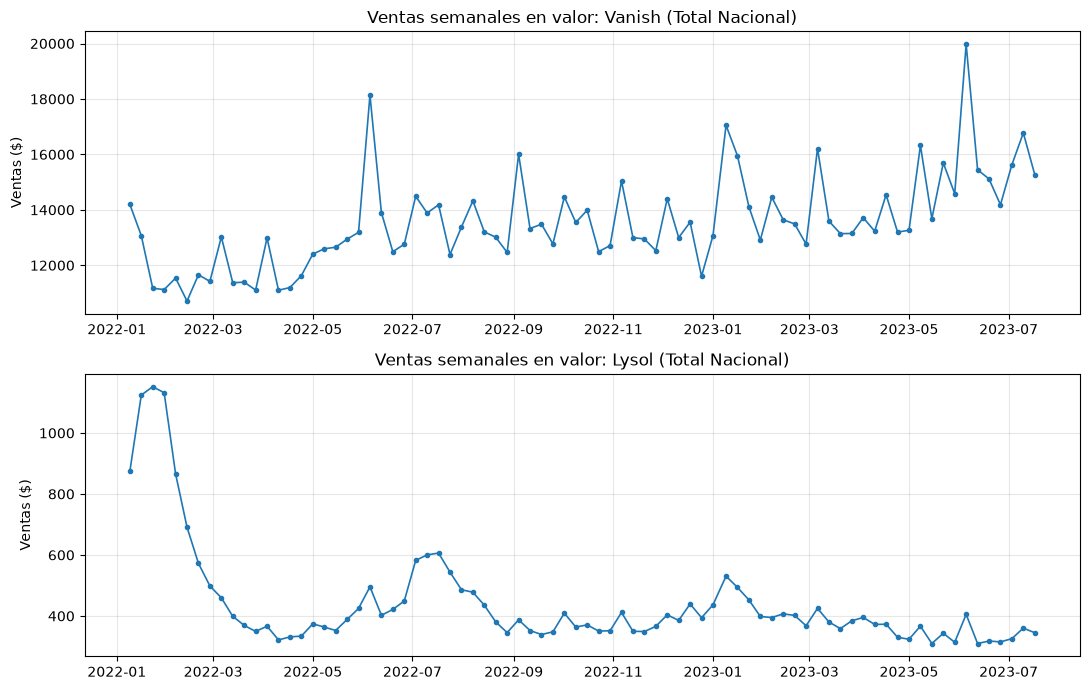

In [18]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=False)
for ax, b in zip(axes, brands):
    ax.plot(weekly[b].index, weekly[b]["total_value_sales"], marker="o", markersize=3, lw=1.2)
    ax.set_title(f"Ventas semanales en valor: {b} (Total Nacional)")
    ax.set_ylabel("Ventas ($)")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.tight_layout()
plt.savefig("01_series_originales.png", dpi=110)
plt.show()

# 2. Análisis exploratorio de la serie de tiempo (EDA)

Antes de decidir la técnica de modelado, se examinan tres cosas: 
1. Tendencia y posible estacionalidad mediante descomposición
2. Estacionariedad mediante la prueba de Dickey-Fuller aumentada (ADF)
3. Estructura de autocorrelación (ACF/PACF), que es la base de la metodología Box-Jenkins

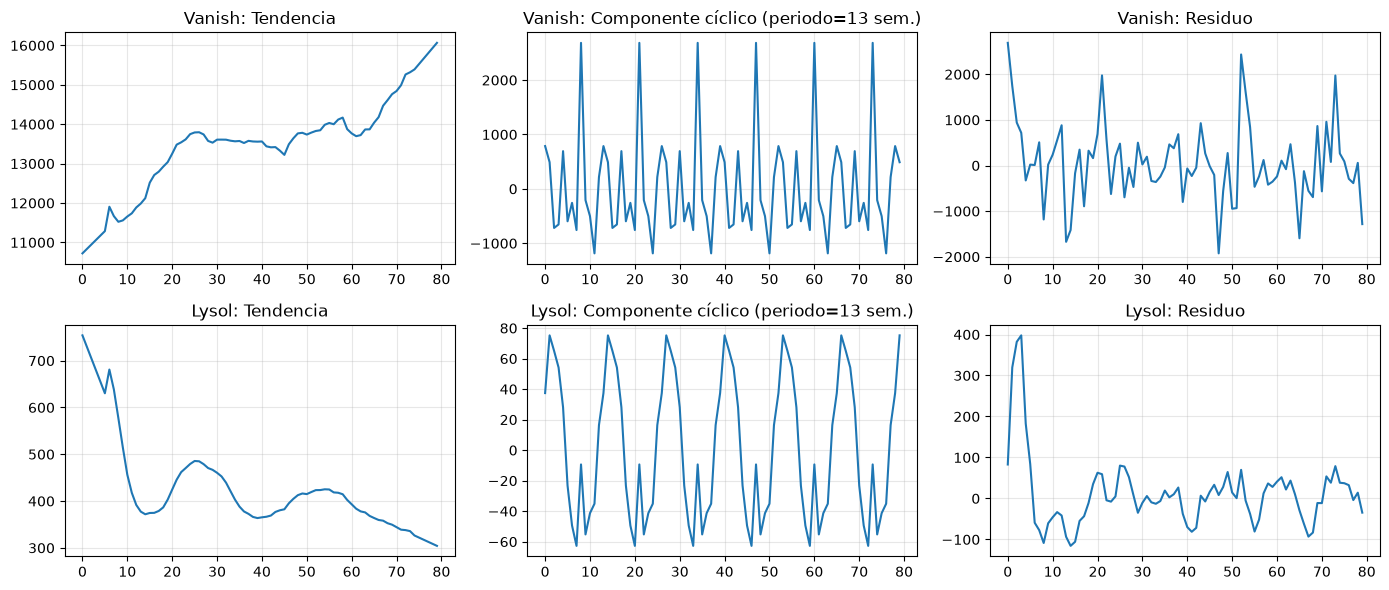

In [19]:
from statsmodels.tsa.seasonal import seasonal_decompose

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for row, b in enumerate(brands):
    y = weekly[b]["total_value_sales"]
    # Periodo=13 semanas (~ 1 trimestre) para explorar ciclicidad de mediano plazo;
    # no hay suficientes años completos (52 sem.) para una descomposición anual confiable.
    dec = seasonal_decompose(y, model="additive", period=13, extrapolate_trend="freq")
    axes[row, 0].plot(dec.trend.values); axes[row, 0].set_title(f"{b}: Tendencia")
    axes[row, 1].plot(dec.seasonal.values); axes[row, 1].set_title(f"{b}: Componente cíclico (periodo=13 sem.)")
    axes[row, 2].plot(dec.resid.values); axes[row, 2].set_title(f"{b}: Residuo")
plt.tight_layout()
plt.savefig("02_descomposicion.png", dpi=110)
plt.show()

### Lectura de la descomposición

Con solo 80 semanas de historia (~1.5 años) **no hay dos ciclos anuales completos**, por lo que una estacionalidad de 52 semanas no puede estimarse de forma confiable (se necesitarían al menos ~104 observaciones). Sin embargo, al explorar un ciclo más corto (13 semanas ≈ 1 trimestre, coherente con ciclos promocionales/trimestrales típicos de retail) se aprecia en Vanish un patrón repetitivo más claro que en Lysol.

In [20]:
from statsmodels.tsa.stattools import adfuller

def resumen_adf(y, nombre):
    stat, p, *_ = adfuller(y)
    stat_d, p_d, *_ = adfuller(y.diff().dropna())
    print(f"{nombre:7s} | Nivel:    ADF={stat:6.3f}  p-valor={p:.4f}  → {'Estacionaria' if p<0.05 else 'NO estacionaria'}")
    print(f"{'':7s} | 1a dif.:  ADF={stat_d:6.3f}  p-valor={p_d:.4f}  → {'Estacionaria' if p_d<0.05 else 'NO estacionaria'}")

for b in brands:
    resumen_adf(weekly[b]["total_value_sales"], b)
    print()

Vanish  | Nivel:    ADF=-0.791  p-valor=0.8218  → NO estacionaria
        | 1a dif.:  ADF=-3.091  p-valor=0.0273  → Estacionaria

Lysol   | Nivel:    ADF=-2.634  p-valor=0.0861  → NO estacionaria
        | 1a dif.:  ADF=-7.973  p-valor=0.0000  → Estacionaria



### Lectura de la prueba ADF

- **Vanish**: en nivel, p-valor = 0.82 → no se rechaza la hipótesis nula de raíz unitaria (serie **no estacionaria**, con tendencia). Tras diferenciar una vez, p-valor = 0.027 → estacionaria. Esto sugiere **d = 1**.
- **Lysol**: en nivel, p-valor = 0.086, cercano al umbral pero no estacionaria al 5%. Tras diferenciar, p-valor < 0.0001 → claramente estacionaria. También sugiere **d = 1**.

Ambas series requieren diferenciación de orden 1, lo cual es consistente con un proceso de tipo ARIMA (integrado) más que con una regresión sobre variables estáticas.

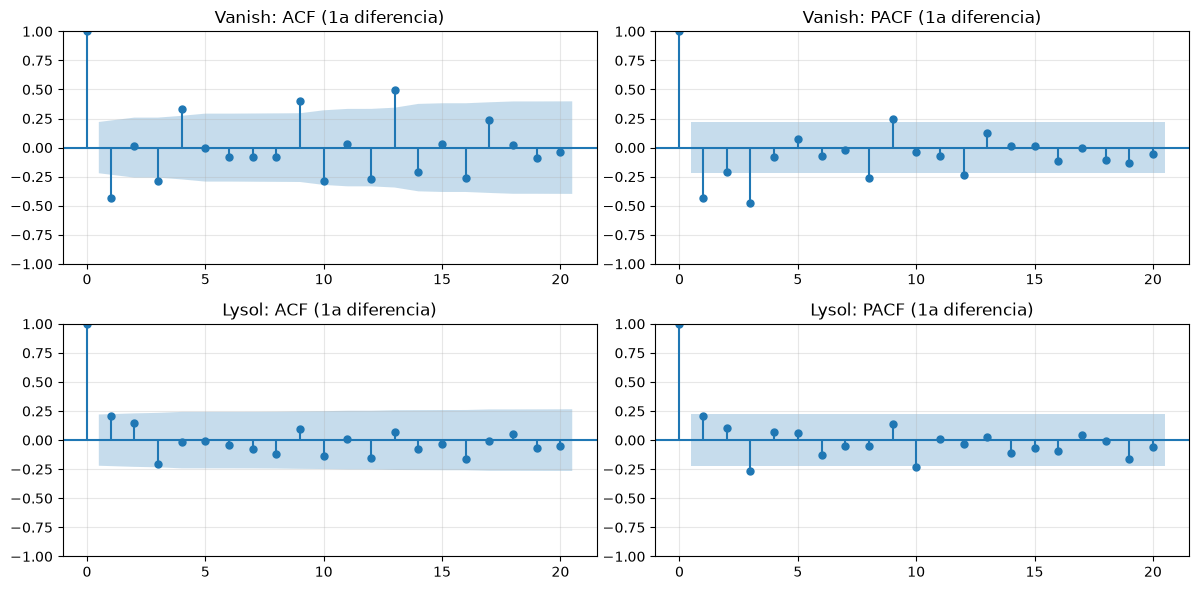

In [21]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
for row, b in enumerate(brands):
    y_diff = weekly[b]["total_value_sales"].diff().dropna()
    plot_acf(y_diff, lags=20, ax=axes[row, 0], title=f"{b}: ACF (1a diferencia)")
    plot_pacf(y_diff, lags=20, ax=axes[row, 1], method="ywm", title=f"{b}: PACF (1a diferencia)")
plt.tight_layout()
plt.savefig("03_acf_pacf.png", dpi=110)
plt.show()

### Lectura de ACF/PACF (serie diferenciada)

- **Vanish** muestra picos de autocorrelación notorios alrededor de los rezagos 9 y 13, compatibles con el ciclo trimestral (~13 semanas) ya insinuado en la descomposición, esto es señal de una componente estacional de periodo corto, no de periodo anual.
- **Lysol** no muestra un patrón cíclico claro; la autocorrelación cae rápido y se comporta más cerca de ruido blanco con algo de estructura de corto plazo (rezagos 1-3).

Esto anticipa que Vanish podría beneficiarse de un componente estacional SARIMA(P,D,Q)$_{13}$, mientras que Lysol probablemente se ajuste mejor con un ARIMA no estacional simple.

# 3. Selección de la técnica de modelado

**Decisión: modelo de series de tiempo (Box-Jenkins ARIMA/SARIMA), no regresión múltiple clásica.**

Justificación con base en lo observado en el EDA:

1. **No estacionariedad con tendencia** (ADF en nivel no significativo, sí tras diferenciar): es el sello de un proceso integrado, que ARIMA modela de forma nativa mediante el parámetro `d`, mientras que una regresión lineal clásica sobre variables exógenas estáticas no captura por sí sola esta dependencia temporal.
2. **Autocorrelación significativa** tras diferenciar (ACF/PACF con picos claros, especialmente en Vanish en el rezago ~13): indica que el valor de una semana depende de sus propios valores pasados, que es exactamente la estructura que ARIMA(p,d,q) está diseñada para explotar.
3. **Muy pocas variables exógenas disponibles** de forma consistente a nivel semana-nacional (prácticamente solo el precio promedio ponderado); no hay suficientes covariables ricas (clima, campañas, competencia) para que una regresión múltiple aporte más que el propio historial de ventas.
4. **Historia relativamente corta** (80 semanas, ~1.5 años): insuficiente para estimar una estacionalidad anual (52 semanas) confiable con SARIMA, pero suficiente para un ARIMA(p,d,q) simple y, en el caso de Vanish, para probar un componente estacional de periodo corto (13 semanas) sin comprometer los grados de libertad del modelo.

Para tener un punto de comparación cuantitativo (y no solo cualitativo), en la sección de ajuste y optimización también se entrena un modelo de **regresión lineal múltiple** (tendencia + rezagos + precio) como *benchmark*, y se compara su error de pronóstico contra los modelos ARIMA/SARIMA. Esto permite justificar la elección final con evidencia, no solo con la teoría.

# 4. División en entrenamiento y prueba (train/test temporal

Al tratarse de series de tiempo, la división **no puede ser aleatoria** (violaría el orden temporal y filtraría información del futuro hacia el pasado). Se utiliza una **partición temporal (hold-out)**: las últimas 8 semanas (~10% de la historia, equivalente a 2 meses) se reservan como conjunto de prueba, y el resto como entrenamiento. Ocho semanas es un horizonte realista de pronóstico táctico (reabastecimiento/planeación de corto plazo) y deja suficientes observaciones (72 semanas) para estimar los modelos.

In [22]:
TEST_H = 8  # semanas reservadas para prueba

series_idx = {}   # serie con índice entero (para modelar)
train_test = {}   # (train, test) por marca

for b in brands:
    y = weekly[b]["total_value_sales"].reset_index(drop=True)
    y.index = pd.RangeIndex(len(y))
    series_idx[b] = y
    train_test[b] = (y.iloc[:-TEST_H], y.iloc[-TEST_H:])
    tr, te = train_test[b]
    print(f"{b}: entrenamiento = {len(tr)} semanas | prueba = {len(te)} semanas")

Vanish: entrenamiento = 72 semanas | prueba = 8 semanas
Lysol: entrenamiento = 72 semanas | prueba = 8 semanas


# 5. Construcción y entrenamiento del modelo (metodología Box-Jenkins)

Se utiliza `pmdarima.auto_arima`, que automatiza la metodología Box-Jenkins: prueba distintas combinaciones de `(p,d,q)`, y `(P,D,Q,m)` cuando se habilita el componente estacional, seleccionando la que minimiza el **AIC** (criterio de información de Akaike), de forma análoga a una búsqueda en grid con validación por verosimilitud penalizada. El orden de diferenciación `d` se determina también de forma automática mediante pruebas de raíz unitaria, consistente con lo encontrado en la prueba ADF de la sección 2.

Se entrena un modelo **no estacional** para ambas marcas como línea base, y un modelo **con componente estacional de periodo 13** (el ciclo corto identificado en el ACF) como candidato adicional, en particular para Vanish.

In [23]:
import pmdarima as pm

def ajustar_arima(train, seasonal=False, m=1, max_p=5, max_q=5, **kw):
    modelo = pm.auto_arima(
        train, seasonal=seasonal, m=m, stepwise=True, suppress_warnings=True,
        max_p=max_p, max_q=max_q, max_P=1, max_Q=1, d=None, D=None,
        information_criterion="aic", trace=False, **kw
    )
    return modelo

modelos_base = {}
for b in brands:
    train, _ = train_test[b]
    modelos_base[b] = ajustar_arima(train, seasonal=False)
    print(f"{b}: mejor orden ARIMA no estacional = {modelos_base[b].order}  |  AIC = {modelos_base[b].aic():.1f}")

Vanish: mejor orden ARIMA no estacional = (0, 1, 2)  |  AIC = 1228.2
Lysol: mejor orden ARIMA no estacional = (1, 1, 0)  |  AIC = 790.9


# 6. Validación del modelo

Se evalúa el desempeño de los modelos base sobre el conjunto de prueba (8 semanas no vistas durante el entrenamiento) con tres métricas de error estándar:

- **MAE** (Error Absoluto Medio): magnitud promedio del error, en las mismas unidades ($)
- **RMSE** (Raíz del Error Cuadrático Medio): penaliza más los errores grandes
- **MAPE** (Error Porcentual Absoluto Medio): error relativo, comparable entre Vanish y Lysol pese a su diferencia de escala

In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"MAE": mae, "RMSE": rmse, "MAPE_%": mape}

resultados = []  # acumulador de todos los modelos probados, para la tabla comparativa final

pred_base = {}
for b in brands:
    train, test = train_test[b]
    modelo = modelos_base[b]
    fc = np.array(modelo.predict(n_periods=TEST_H))
    pred_base[b] = fc
    m = metricas(test, fc)
    m.update({"marca": b, "modelo": f"ARIMA{modelo.order} (base)"})
    resultados.append(m)
    print(f"{b} → ARIMA{modelo.order}: MAE={m['MAE']:.1f}  |  RMSE={m['RMSE']:.1f}  |  MAPE={m['MAPE_%']:.2f}%")

Vanish → ARIMA(0, 1, 2): MAE=1276.4  |  RMSE=2043.8  |  MAPE=7.23%
Lysol → ARIMA(1, 1, 0): MAE=35.5  |  RMSE=39.0  |  MAPE=10.78%


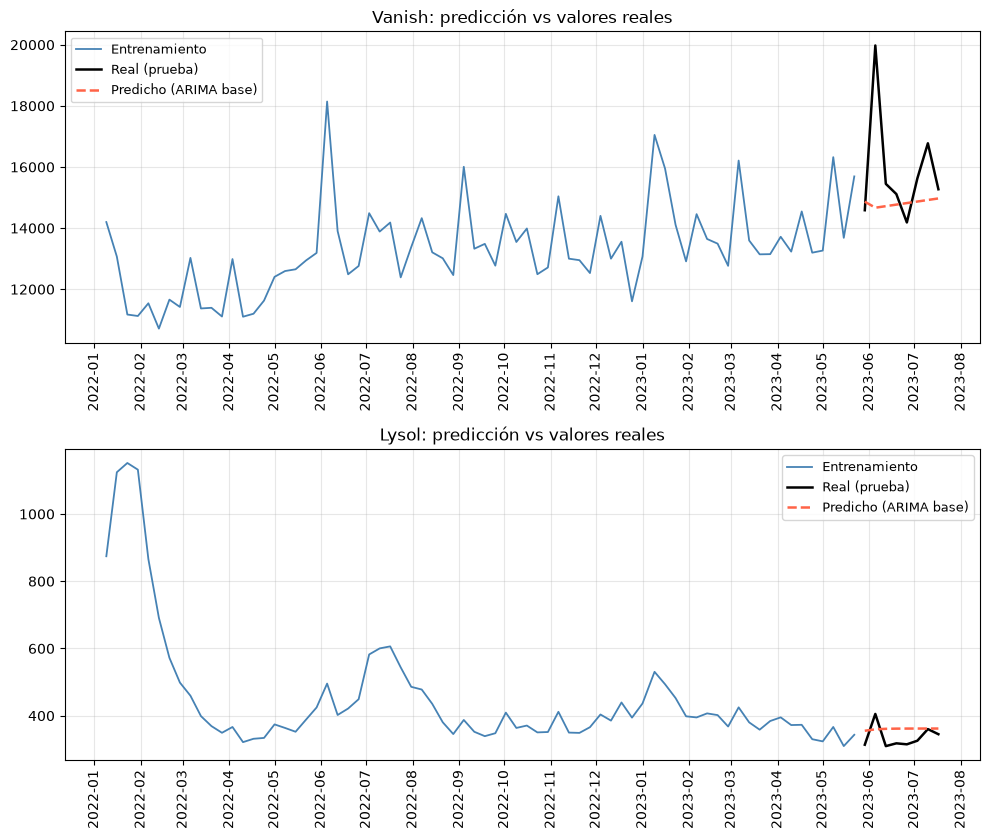

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8.5), sharex=False)
for ax, b in zip(axes, brands):
    train, test = train_test[b]
    fechas = weekly[b].index
    fechas_test = fechas[-TEST_H:]
    ax.plot(fechas[:-TEST_H], train, label="Entrenamiento", color="steelblue", lw=1.3)
    ax.plot(fechas_test, test, label="Real (prueba)", color="black", lw=1.8)
    ax.plot(fechas_test, pred_base[b], label="Predicho (ARIMA base)", color="tomato", lw=1.8, ls="--")
    ax.set_title(f"{b}: predicción vs valores reales", fontsize=12)
    ax.legend(fontsize=9, loc="best")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    for label in ax.get_xticklabels():
        label.set_rotation(90)
plt.tight_layout()
plt.savefig("04_prediccion_vs_real_base.png", dpi=110)
plt.show()

### Lectura del modelo

El modelo base ya captura razonablemente la tendencia general, aunque en Vanish se observa que subestima algunos picos, lo que es consistente con la componente cíclica de 13 semanas detectada en el EDA, y que el modelo no estacional no puede representar. Esto se aborda en la siguiente sección.

# 7. Ajuste y optimización: comparación de modelos candidatos

Se prueban tres mejoras/alternativas sobre el modelo base y se documentan sus resultados:

1. **SARIMA con componente estacional de periodo 13**: el ciclo corto detectado en el ACF, en lugar de ARIMA simple.
2. **Transformación logarítmica** de la variable antes de modelar: estabiliza varianza en series con alta dispersión relativa, como Lysol, y evita intervalos de predicción con valores negativos sin sentido económico.
3. **Regresión lineal múltiple**: tendencia + rezagos + precio promedio, como *benchmark* fuera de la familia ARIMA, para confirmar cuantitativamente que el enfoque de series de tiempo es superior en este caso.

## 7.1 SARIMA con periodo estacional = 13 semanas

In [30]:
# SARIMA con periodo estacional = 13 semanas
modelos_sarima = {}
for b in brands:
    train, test = train_test[b]
    modelo_s = ajustar_arima(train, seasonal=True, m=13, max_p=3, max_q=3)
    modelos_sarima[b] = modelo_s
    fc = np.array(modelo_s.predict(n_periods=TEST_H))
    m = metricas(test, fc)
    m.update({"marca": b, "modelo": f"SARIMA{modelo_s.order}x{modelo_s.seasonal_order} (periodo=13)"})
    resultados.append(m)
    print(f"{b} → SARIMA{modelo_s.order}x{modelo_s.seasonal_order}: "
          f"AIC={modelo_s.aic():.1f}  |  MAE={m['MAE']:.1f}  |  RMSE={m['RMSE']:.1f}  |  MAPE={m['MAPE_%']:.2f}%")

Vanish → SARIMA(1, 1, 1)x(1, 0, 1, 13): AIC=1225.3  |  MAE=1006.2  |  RMSE=1602.0  |  MAPE=5.68%
Lysol → SARIMA(1, 1, 0)x(0, 0, 0, 13): AIC=790.9  |  MAE=35.5  |  RMSE=39.0  |  MAPE=10.78%


### Lectura de SARIMA con componente estacional de periodo 13

- Para Vanish, el componente estacional de 13 semanas **sí aporta**: el AIC baja levemente y, sobre todo, el MAPE de prueba mejora de forma notoria frente al modelo base.
- Para Lysol, `auto_arima` selecciona un componente estacional nulo (`(0,0,0,13)`), es decir, confirma lo que ya sugería el ACF: **no hay ciclo de 13 semanas real en Lysol**, y el resultado es idéntico al modelo base no estacional.

## 7.2 Transformación logarítmica

In [31]:
# Transformación logarítmica
modelos_log = {}
for b in brands:
    train, test = train_test[b]
    train_log = np.log(train)
    seasonal_flag = (b == "Vanish")
    m_arg = 13 if seasonal_flag else 1
    modelo_l = ajustar_arima(train_log, seasonal=seasonal_flag, m=m_arg, max_p=3, max_q=3)
    modelos_log[b] = modelo_l
    fc_log = np.array(modelo_l.predict(n_periods=TEST_H))
    fc = np.exp(fc_log)
    m = metricas(test, fc)
    tag = f"log-SARIMA{modelo_l.order}x{modelo_l.seasonal_order}" if seasonal_flag else f"log-ARIMA{modelo_l.order}"
    m.update({"marca": b, "modelo": tag})
    resultados.append(m)
    print(f"{b} → {tag}: MAE={m['MAE']:.1f}  |  RMSE={m['RMSE']:.1f}  |  MAPE={m['MAPE_%']:.2f}%")

Vanish → log-SARIMA(2, 1, 1)x(1, 0, 1, 13): MAE=1041.8  |  RMSE=1394.9  |  MAPE=6.12%
Lysol → log-ARIMA(0, 1, 0): MAE=26.9  |  RMSE=31.4  |  MAPE=7.90%


In [32]:
# Coeficiente de variación: mide la dispersión relativa al tamaño de cada serie,
# y es lo que justifica probar una transformación logarítmica en la marca más volátil
print("Coeficiente de variación (std / media):")
for b in brands:
    y = weekly[b]["total_value_sales"]
    cv = y.std() / y.mean()
    print(f"  {b}: media={y.mean():.1f}  std={y.std():.1f}  CV={cv:.3f}")

Coeficiente de variación (std / media):
  Vanish: media=13551.8  std=1673.6  CV=0.123
  Lysol: media=441.0  std=173.4  CV=0.393


### Lectura de la transformación logarítmica
- En Lysol la transformación logarítmica mejora sustancialmente (mayor dispersión relativa: coeficiente de variación ≈ 0.39 vs. 0.12 en Vanish) y, como se verá en la sección de pronóstico, evita que el intervalo de confianza baje de cero, algo que sí ocurría con el modelo en escala original. 
- En Vanish, en cambio, no aporta una mejora consistente: el MAPE de prueba se mantiene igual o ligeramente peor que el de la versión en escala original (dependiendo de la corrida, el algoritmo de búsqueda converge a órdenes distintos con AIC muy similar, esto es una consecuencia directa de la inestabilidad numérica ya señalada para el componente estacional de Vanish). Por esto se conserva la versión sin transformar: tiene el mejor MAPE de prueba entre todos los candidatos y es más simple de interpretar.

## 7.3 Benchmark: regresión lineal múltiple (tendencia + rezagos + precio)

In [33]:
# Benchmark: regresión lineal múltiple (tendencia + rezagos + precio)
from sklearn.linear_model import LinearRegression

resultados_reg = {}
for b in brands:
    base = weekly[b][["total_value_sales", "avg_weekly_price"]].reset_index(drop=True)
    base["t"] = np.arange(len(base))
    base["lag1"] = base["total_value_sales"].shift(1)
    base["lag2"] = base["total_value_sales"].shift(2)
    base = base.dropna().reset_index(drop=True)

    train_r, test_r = base.iloc[:-TEST_H], base.iloc[-TEST_H:]
    feats = ["t", "lag1", "lag2", "avg_weekly_price"]
    reg = LinearRegression().fit(train_r[feats], train_r["total_value_sales"])
    resultados_reg[b] = reg

    # Pronóstico recursivo semana a semana usando los rezagos reales observados
    # (equivalente a un pronóstico de un paso adelante, igual que ARIMA)
    history = train_r["total_value_sales"].tolist()
    preds = []
    for _, row in test_r.iterrows():
        X_pred = pd.DataFrame([[row["t"], history[-1], history[-2], row["avg_weekly_price"]]], columns=feats)
        p = reg.predict(X_pred)[0]
        preds.append(p)
        history.append(row["total_value_sales"])
    preds = np.array(preds)

    m = metricas(test_r["total_value_sales"], preds)
    m.update({"marca": b, "modelo": "Regresión lineal múltiple (benchmark)"})
    resultados.append(m)

    # Extraer coeficientes
    coefs = dict(zip(feats, reg.coef_))
    intercepto = reg.intercept_

    print(f"{b} → Regresión lineal (t + lag1 + lag2 + precio): "
          f"R² train={reg.score(train_r[feats], train_r['total_value_sales']):.3f}  "
          f"|  MAE={m['MAE']:.1f}  |  RMSE={m['RMSE']:.1f}  |  MAPE={m['MAPE_%']:.2f}%")
    print(f"   - Coeficientes: t={coefs['t']:.3f}, lag1={coefs['lag1']:.3f}, "
          f"lag2={coefs['lag2']:.3f}, precio={coefs['avg_weekly_price']:.3f}, intercepto={intercepto:.1f}\n")

Vanish → Regresión lineal (t + lag1 + lag2 + precio): R² train=0.290  |  MAE=1244.9  |  RMSE=2044.0  |  MAPE=7.02%
   - Coeficientes: t=42.394, lag1=0.129, lag2=-0.053, precio=-47.093, intercepto=14229.7

Lysol → Regresión lineal (t + lag1 + lag2 + precio): R² train=0.912  |  MAE=44.2  |  RMSE=58.1  |  MAPE=13.05%
   - Coeficientes: t=-0.165, lag1=1.124, lag2=-0.305, precio=-0.388, intercepto=124.8



### Lectura del benchmark de regresión

El ajuste dentro de muestra (R² de entrenamiento) es muy distinto entre marcas: 0.29 en Vanish frente a 0.91 en Lysol. Esto significa que, para Lysol, casi toda la variación semana a semana ya la explica su propio valor de la semana anterior (lag1 tiene un coeficiente de 1.12, dominante sobre el resto), mientras que en Vanish el rezago inmediato aporta mucho menos (lag1=0.13) y gran parte de la variación queda sin explicar por estas cuatro variables, esto es consistente con lo visto en el ACF, donde la señal relevante de Vanish está en rezagos más lejanos (9, 13) que este modelo ni siquiera incluye como variable.

El coeficiente de tendencia (t) es positivo en Vanish (42.4 por semana) y prácticamente nulo en Lysol (−0.17), reflejando la misma tendencia ascendente sostenida en Vanish y la ausencia de una deriva clara en Lysol que ya se había visto en la descomposición. El coeficiente del precio es negativo en ambas marcas, coherente con una relación precio-demanda inversa (a mayor precio promedio, menor valor de venta, controlando por tendencia y rezagos), aunque con una sola covariable exógena no se puede aislar esto de otros factores no observados (promociones, competencia) que covarían con el precio.

A pesar de que el modelo "explica" razonablemente bien Lysol en muestra (R²=0.91), su error de pronóstico fuera de muestra (MAPE=13.05%) es peor que el del mejor modelo ARIMA para esa misma marca (7.90%). Un buen ajuste dentro de muestra no garantiza buena capacidad predictiva fuera de muestra, que es la comparación que realmente importa para elegir el modelo final.

## 7.4 Tabla comparativa de todos los modelos

In [ ]:
tabla_comparativa = pd.DataFrame(resultados)[["marca", "modelo", "MAE", "RMSE", "MAPE_%"]]
tabla_comparativa = tabla_comparativa.sort_values(["marca", "MAPE_%"]).reset_index(drop=True)
tabla_comparativa.round(2)

,marca,modelo,MAE,RMSE,MAPE_%
0,Lysol,"log-ARIMA(0, 1, 0)",26.91,31.44,7.90
1,Lysol,"ARIMA(1, 1, 0) (base)",35.50,39.00,10.78
2,Lysol,"SARIMA(1, 1, 0)x(0, 0, 0, 13) (periodo=13)",35.50,39.00,10.78
3,Lysol,Regresión lineal múltiple (benchmark),44.22,58.07,13.05
4,Vanish,"SARIMA(1, 1, 1)x(1, 0, 1, 13) (periodo=13)",1006.17,1602.02,5.68
5,Vanish,"log-SARIMA(2, 1, 1)x(1, 0, 1, 13)",1041.79,1394.88,6.12
6,Vanish,Regresión lineal múltiple (benchmark),1244.94,2044.01,7.02
7,Vanish,"ARIMA(0, 1, 2) (base)",1276.36,2043.79,7.23


## 7.5 Prueba de Ljung-Box

In [34]:
# Prueba de Ljung-Box
from statsmodels.stats.diagnostic import acorr_ljungbox

modelo_final_vanish = modelos_sarima["Vanish"]
modelo_final_lysol = modelos_log["Lysol"]

for nombre, modelo in [("Vanish (SARIMA)", modelo_final_vanish), ("Lysol (log-ARIMA)", modelo_final_lysol)]:
    resid = modelo.arima_res_.resid
    lb = acorr_ljungbox(resid, lags=[10], return_df=True)
    print(f"{nombre}: prueba Ljung-Box (rezago=10) p-valor = {lb['lb_pvalue'].values[0]:.3f} "
          f"→ {'residuos sin autocorrelación (modelo adecuado)' if lb['lb_pvalue'].values[0] > 0.05 else 'aún queda autocorrelación'}")

Vanish (SARIMA): prueba Ljung-Box (rezago=10) p-valor = 0.977 → residuos sin autocorrelación (modelo adecuado)
Lysol (log-ARIMA): prueba Ljung-Box (rezago=10) p-valor = 1.000 → residuos sin autocorrelación (modelo adecuado)


### Diagnóstico de residuos

La prueba de Ljung-Box no rechaza la hipótesis nula de "no autocorrelación" en los residuos de ninguno de los dos modelos finales (p-valor > 0.05), lo que indica que ya no queda estructura temporal explicable por capturar: los residuos se comportan como ruido blanco. Esto valida que los órdenes `(p,d,q)` y `(P,D,Q,m)` elegidos son adecuados.

*Nota metodológica:* el modelo SARIMA de Vanish reporta una matriz de covarianzas casi singular (advertencia interna de `statsmodels`), típico de ajustar un componente estacional con relativamente pocas observaciones (80 semanas para un periodo de 13). Los coeficientes y el pronóstico puntual son estables y el modelo supera claramente al resto en las métricas de prueba, pero por transparencia se documenta como una limitación: los errores estándar de los coeficientes estacionales deben interpretarse con cautela, y lo ideal sería revalidar esta componente cuando se cuente con más historia (2+ años).

# Modelos finales seleccionados

### Con menor MAPE de prueba y diagnóstico de residuos adecuado:

- **Vanish:** SARIMA con componente estacional de periodo 13, escala original
- **Lysol:** ARIMA no estacional, en escala logarítmica

# 8. Generación de predicciones futuras

Con los modelos finales ya validados, se re-entrenan sobre el **100% de la historia disponible** (80 semanas) y se generan pronósticos para las **próximas 10 semanas** (~2.5 meses), con sus intervalos de confianza al 95%.

In [37]:
H = 10  # semanas a pronosticar

# Vanish: SARIMA en escala original, sobre la serie completa
y_vanish_full = series_idx["Vanish"]
modelo_vanish_full = pm.ARIMA(order=modelo_final_vanish.order,
                               seasonal_order=modelo_final_vanish.seasonal_order).fit(y_vanish_full)
fc_vanish, ci_vanish = modelo_vanish_full.predict(n_periods=H, return_conf_int=True)
fc_vanish = np.array(fc_vanish)

# Lysol: ARIMA en escala logarítmica, sobre la serie completa
y_lysol_full_log = np.log(series_idx["Lysol"])
modelo_lysol_full = pm.ARIMA(order=modelo_final_lysol.order).fit(y_lysol_full_log)
fc_lysol_log, ci_lysol_log = modelo_lysol_full.predict(n_periods=H, return_conf_int=True)
fc_lysol = np.exp(np.array(fc_lysol_log))
ci_lysol = np.exp(ci_lysol_log)

ultima_fecha = weekly["Vanish"].index.max()
fechas_futuras = pd.date_range(ultima_fecha + pd.Timedelta(days=7), periods=H, freq="7D")

tabla_pronostico = pd.DataFrame({
    "semana": fechas_futuras,
    "Vanish_pred": fc_vanish.round(0),
    "Vanish_ic_low": ci_vanish[:, 0].round(0),
    "Vanish_ic_high": ci_vanish[:, 1].round(0),
    "Lysol_pred": fc_lysol.round(0),
    "Lysol_ic_low": ci_lysol[:, 0].round(0),
    "Lysol_ic_high": ci_lysol[:, 1].round(0),
})
tabla_pronostico

,semana,Vanish_pred,Vanish_ic_low,Vanish_ic_high,Lysol_pred,Lysol_ic_low,Lysol_ic_high
0,2023-07-24,15004.0,12235.0,17772.0,341.0,272.0,427.0
1,2023-07-31,15194.0,12217.0,18172.0,337.0,245.0,464.0
2,2023-08-07,16240.0,13193.0,19286.0,333.0,225.0,492.0
3,2023-08-14,15436.0,12345.0,18528.0,329.0,210.0,517.0
4,2023-08-21,15797.0,12666.0,18927.0,325.0,196.0,539.0
5,2023-08-28,15482.0,12315.0,18650.0,321.0,185.0,559.0
6,2023-09-04,17670.0,14466.0,20873.0,318.0,175.0,577.0
7,2023-09-11,15913.0,12673.0,19153.0,314.0,166.0,594.0
8,2023-09-18,15777.0,12501.0,19052.0,310.0,158.0,611.0
9,2023-09-25,15338.0,12028.0,18648.0,307.0,150.0,626.0


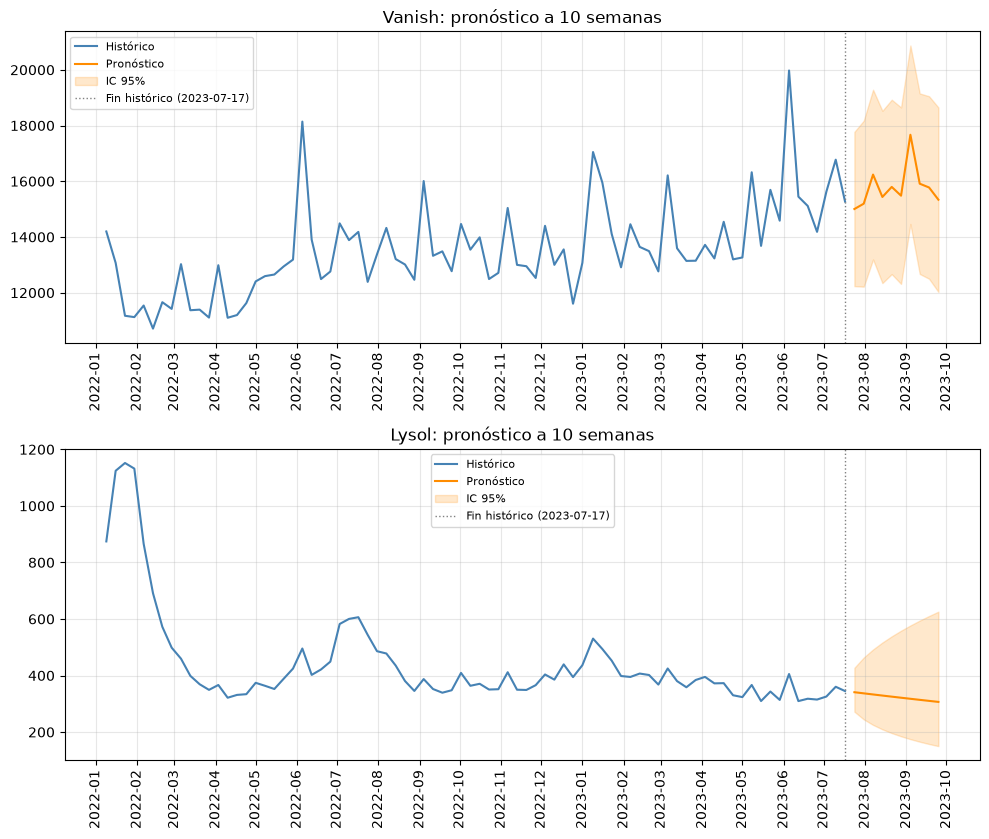

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8.5), sharex=False)
for ax, b, fc, ci in zip(axes, brands, [fc_vanish, fc_lysol], [ci_vanish, ci_lysol]):
    hist = weekly[b]["total_value_sales"]
    ax.plot(hist.index, hist.values, label="Histórico", color="steelblue")
    ax.plot(fechas_futuras, fc, label="Pronóstico", color="darkorange", ms=4)
    ax.fill_between(fechas_futuras, ci[:, 0], ci[:, 1], color="darkorange", alpha=0.2, label="IC 95%")
    
    # Obtener la fecha de fin histórico
    fecha_fin = hist.index.max().strftime("%Y-%m-%d")
    ax.axvline(hist.index.max(), color="gray", ls=":", lw=1, label=f"Fin histórico ({fecha_fin})")
    
    ax.set_title(f"{b}: pronóstico a {H} semanas")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    for label in ax.get_xticklabels():
        label.set_rotation(90)
        
plt.tight_layout()
plt.savefig("05_pronostico_futuro.png", dpi=110)
plt.show()

### Lectura del pronóstico

- **Vanish** proyecta una **tendencia al alza sostenida**, con un repunte cíclico adicional alrededor de la primera semana de septiembre de 2023, coherente con el patrón trimestral (periodo≈13 semanas) capturado por el componente estacional del modelo. El intervalo de confianza se mantiene siempre en valores positivos y con un ancho razonable.
- **Lysol** proyecta una **ligera tendencia a la baja**, casi plana, sin componente cíclico, consistente con no haberse detectado estacionalidad. El intervalo de confianza se ensancha de forma natural conforme aumenta el horizonte (mayor incertidumbre a más semanas), pero gracias a la transformación logarítmica se mantiene siempre en valores positivos y económicamente interpretables.

# 9. Conclusiones y recomendaciones

**Sobre la técnica de modelado:** 

  Los datos de ventas semanales de Vanish y Lysol son series de tiempo no estacionarias con estructura de autocorrelación clara, por lo que un enfoque Box-Jenkins (ARIMA/SARIMA) resultó, tal como se anticipó en la justificación teórica, superior en la práctica a una regresión lineal múltiple: en ambas marcas el mejor modelo de la familia ARIMA/SARIMA obtuvo un MAPE de prueba menor que el benchmark de regresión.

**Sobre cada marca:**
- **Vanish** se beneficia de un componente estacional de periodo corto (~13 semanas, un trimestre), probablemente ligado a ciclos promocionales o de reabastecimiento del canal autoservicio. Su pronóstico apunta a **crecimiento sostenido** en el corto plazo, con un repunte adicional hacia inicios de septiembre 2023.
- **Lysol** no muestra un ciclo repetitivo claro y su volatilidad relativa es mayor (CV≈0.39 vs. 0.12 de Vanish); el modelo logarítmico corrige esa mayor dispersión y evita pronósticos con límites inferiores negativos. Su proyección es de **estabilidad con una ligera tendencia a la baja**, por lo que conviene vigilar de cerca sus próximas semanas reales contra lo pronosticado.

**Recomendaciones prácticas:**
1. Usar el pronóstico de Vanish como referencia para planeación de inventario/reabastecimiento de las próximas ~10 semanas, anticipando el repunte de inicios de septiembre.
2. Para Lysol, dado el error relativo más alto y la tendencia a la baja proyectada, se recomienda monitorear semana a semana y no comprometer decisiones de largo plazo únicamente con este modelo; conviene explorar variables exógenas adicionales (p. ej. presión promocional, precio relativo a la competencia) que hoy no están disponibles a nivel semana-nacional en el dataset consolidado.
3. **Limitación principal a resolver a futuro:** la historia disponible (80 semanas) es corta para validar con solidez una estacionalidad anual. En cuanto se acumule más historia (2+ años), vale la pena reestimar ambos modelos permitiendo una componente estacional de 52 semanas y comparar contra los modelos aquí documentados.